In [1]:
from pathlib import Path
import copy
import random

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from scipy.ndimage import gaussian_filter
from sklearn.metrics import auc, roc_curve
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader

# Reproducibility and shared locations
SEED = 12345
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_DIR = Path("/pscratch/sd/m/mcohen54/rajat_data/saved_datasets")
MODEL_DIR = Path("/pscratch/sd/m/mcohen54/rajat_data/trained_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 512
INFERENCE_BATCH_SIZE = 8192
NUM_WORKERS = 4
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 8
SIGNAL_TAGS = ["Ato4l", "hChToTauNu", "hToTauTau", "leptoquark"]
TARGET_KEYS = {"KL": "KL_AD_scores", "MSE": "MSE_AD_scores"}

print(f"Using device: {DEVICE}")
print(f"Datasets: {DATA_DIR}")
print(f"Models:   {MODEL_DIR}")

Using device: cuda
Datasets: /pscratch/sd/m/mcohen54/rajat_data/saved_datasets
Models:   /pscratch/sd/m/mcohen54/rajat_data/trained_models


In [2]:
def load_subdicts_from_h5(save_dir, tags_to_use=None):
    """Load each HDF5 file in ``save_dir`` into a nested dictionary."""
    save_dir = Path(save_dir)
    requested = set(tags_to_use) if tags_to_use is not None else None
    main_dict = {}

    if not save_dir.is_dir():
        raise FileNotFoundError(f"Dataset directory does not exist: {save_dir}")

    for file_path in sorted(save_dir.glob("*.h5")):
        tag = file_path.stem
        if requested is not None and tag not in requested:
            continue
        with h5py.File(file_path, "r") as handle:
            main_dict[tag] = {key: np.asarray(handle[key]) for key in handle}
        print(f"Loaded {tag} from {file_path}")

    if requested is not None:
        missing = requested.difference(main_dict)
        if missing:
            raise FileNotFoundError(f"Missing datasets for tags: {sorted(missing)}")
    return main_dict

In [3]:
required_tags = ["train", "val", "Background", *SIGNAL_TAGS]
datasets = load_subdicts_from_h5(DATA_DIR, tags_to_use=required_tags)

required_keys = {"data", *TARGET_KEYS.values()}
for tag, data_dict in datasets.items():
    missing = required_keys.difference(data_dict)
    if missing:
        raise KeyError(f"Dataset '{tag}' is missing keys: {sorted(missing)}")

Loaded Ato4l from /pscratch/sd/m/mcohen54/rajat_data/saved_datasets/Ato4l.h5
Loaded Background from /pscratch/sd/m/mcohen54/rajat_data/saved_datasets/Background.h5
Loaded hChToTauNu from /pscratch/sd/m/mcohen54/rajat_data/saved_datasets/hChToTauNu.h5
Loaded hToTauTau from /pscratch/sd/m/mcohen54/rajat_data/saved_datasets/hToTauTau.h5
Loaded leptoquark from /pscratch/sd/m/mcohen54/rajat_data/saved_datasets/leptoquark.h5
Loaded train from /pscratch/sd/m/mcohen54/rajat_data/saved_datasets/train.h5
Loaded val from /pscratch/sd/m/mcohen54/rajat_data/saved_datasets/val.h5


In [4]:
for tag, data_dict in datasets.items():
    print(f"Tag: {tag}")
    for key, value in data_dict.items():
        print(f"  {key}: {value.shape}")

Tag: Ato4l
  KL_AD_scores: (55969,)
  MSE_AD_scores: (55969,)
  clipped_KL_AD_scores: (55969,)
  data: (55969, 57)
  large_student_AD_scores: (55969,)
  medium_student_AD_scores: (55969,)
  small_student_AD_scores: (55969,)
Tag: Background
  KL_AD_scores: (200000,)
  MSE_AD_scores: (200000,)
  clipped_KL_AD_scores: (200000,)
  data: (200000, 57)
  large_student_AD_scores: (200000,)
  medium_student_AD_scores: (200000,)
  small_student_AD_scores: (200000,)
Tag: hChToTauNu
  KL_AD_scores: (760272,)
  MSE_AD_scores: (760272,)
  clipped_KL_AD_scores: (760272,)
  data: (760272, 57)
  large_student_AD_scores: (760272,)
  medium_student_AD_scores: (760272,)
  small_student_AD_scores: (760272,)
Tag: hToTauTau
  KL_AD_scores: (691283,)
  MSE_AD_scores: (691283,)
  clipped_KL_AD_scores: (691283,)
  data: (691283, 57)
  large_student_AD_scores: (691283,)
  medium_student_AD_scores: (691283,)
  small_student_AD_scores: (691283,)
Tag: leptoquark
  KL_AD_scores: (340544,)
  MSE_AD_scores: (340544,)


In [5]:
def plot_roc_curves(datasets, AD_score_type='MSE_AD_scores'):
    plt.figure(figsize=(8, 5))

    bkg_scores = datasets['Background'][AD_score_type]
    bkg_labels = np.zeros_like(bkg_scores)

    skip_tags = ['Background', 'train', 'val']

    for tag, data_dict in datasets.items():
        if tag in skip_tags: continue

        sig_scores = data_dict[AD_score_type]
        combined_scores = np.concatenate([bkg_scores, sig_scores])
        combined_labels = np.concatenate([bkg_labels, np.ones_like(sig_scores)])

        fpr, tpr, thresholds = roc_curve(y_true=combined_labels, y_score=combined_scores)
        roc_auc = auc(fpr, tpr)

        threshold_idx = np.argmin(np.abs(fpr - 1e-5))
        threshold_tpr = tpr[threshold_idx]


        plt.plot(fpr, tpr, label=f'{tag} (AUC = {roc_auc:.2f}, $\epsilon$ = {threshold_tpr:.2e})', linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.axvline(x=1e-5, color='red', linestyle='--')
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves: {AD_score_type}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_73685/2752484985.py:23: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(fpr, tpr, label=f'{tag} (AUC = {roc_auc:.2f}, $\epsilon$ = {threshold_tpr:.2e})', linewidth=2)


In [6]:
# Architecture grids used in the later studies. The current configurations
# (32) and (64, 32) are retained as baselines alongside the requested variants.
MEDIUM_WIDTHS = [1, 4, 8, 16, 32, 64]
LARGE_WIDTHS = [(4, 32), (16, 16), (16, 32), (32, 32), (64, 32), (64, 64)]

In [7]:
class StudentNetSmall(nn.Module):
    def __init__(self, input_dim=57):
        super(StudentNetSmall, self).__init__()
        # Just one Linear layer: [input_dim] → [1]
        self.fc = nn.Linear(input_dim, 1)

    def forward(self, x):
        # x: (batch_size, 57)
        out = self.fc(x)  # → (batch_size, 1)
        return out


# -- Medium network: one hidden layer --
class StudentNetMedium(nn.Module):
    def __init__(self, input_dim=57, hidden_dim=64):
        super(StudentNetMedium, self).__init__()
        # Linear → ReLU → Linear
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch_size, 57)
        h = self.act(self.fc1(x))  # → (batch_size, hidden_dim)
        out = self.fc2(h)          # → (batch_size, 1)
        return out


# -- Large network: two hidden layers --
class StudentNetLarge(nn.Module):
    def __init__(self, input_dim=57, hidden1=128, hidden2=64):
        super(StudentNetLarge, self).__init__()
        # Linear → ReLU → Linear → ReLU → Linear
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.act1 = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.act2 = nn.ReLU(inplace=True)
        self.fc3 = nn.Linear(hidden2, 1)

    def forward(self, x):
        # x: (batch_size, 57)
        h1 = self.act1(self.fc1(x))  # → (batch_size, hidden1)
        h2 = self.act2(self.fc2(h1)) # → (batch_size, hidden2)
        out = self.fc3(h2)           # → (batch_size, 1)
        return out

In [8]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from typing import Optional, Dict, Any
import os


class Trainer:
    """
    Trainer class for regression models (e.g., StudentNetSmall/Medium/Large) in PyTorch.
    Handles training, validation, checkpointing, and learning‐rate scheduling.
    """

    def __init__(
        self,
        model: nn.Module,
        train_loader: torch.utils.data.DataLoader,
        val_loader: torch.utils.data.DataLoader,
        device: Optional[torch.device] = None,
        lr: float = 1e-3,
        weight_decay: float = 0.0,
        scheduler_params: Optional[Dict[str, Any]] = None,
        checkpoint_dir: str = "./checkpoints",
    ):
        """
        Args:
            model:             The PyTorch model to train.
            train_loader:      DataLoader for the training set. Batches should yield (features, targets).
            val_loader:        DataLoader for the validation set. Batches should yield (features, targets).
            device:            torch.device (e.g., torch.device("cuda") or torch.device("cpu")).
                               If None, defaults to "cuda" if available, else "cpu".
            lr:                Initial learning rate for Adam.
            weight_decay:      Weight‐decay (L2 penalty) for Adam.
            scheduler_params:  Dict of parameters for ReduceLROnPlateau scheduler.
                               Keys may include "mode", "factor", "patience", "min_lr", etc.
                               If None, defaults to {"mode": "min", "factor": 0.5, "patience": 5, "min_lr": 1e-6}.
            checkpoint_dir:    Directory where best‐model checkpoints and logs will be saved.
        """
        # Device setup
        if device is None:
            self.device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
        else:
            self.device = device

        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.val_loader = val_loader

        # Loss function
        self.criterion = nn.MSELoss()

        # Optimizer
        self.optimizer = Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)

        # LR Scheduler (ReduceLROnPlateau)
        default_sched = {"mode": "min", "factor": 0.5, "patience": 5, "min_lr": 1e-6, "verbose": True}
        sched_params = scheduler_params or default_sched
        self.scheduler = ReduceLROnPlateau(self.optimizer, **sched_params)

        # Checkpoint directory
        os.makedirs(checkpoint_dir, exist_ok=True)
        self.checkpoint_dir = checkpoint_dir

        # Internal bookkeeping
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "lr": [],
        }
        self.best_val_loss = float("inf")
        self.best_epoch = -1

    def train_epoch(self) -> float:
        """
        Runs one full training epoch.
        Returns:
            Average training loss over all batches in this epoch.
        """
        self.model.train()
        running_loss = 0.0
        total_samples = 0

        for batch in self.train_loader:
            # Assume batch is (features, targets)
            x_batch, y_batch = batch
            x_batch = x_batch.to(self.device, dtype=torch.float32)
            y_batch = y_batch.to(self.device, dtype=torch.float32).view(-1, 1)

            # Zero gradients
            self.optimizer.zero_grad()

            # Forward pass
            preds = self.model(x_batch)
            loss = self.criterion(preds, y_batch)

            # Backward + optimize
            loss.backward()
            self.optimizer.step()

            # Accumulate
            batch_size = x_batch.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

        avg_loss = running_loss / total_samples
        return avg_loss

    def validate(self) -> float:
        """
        Runs one full validation pass (no gradient computation).
        Returns:
            Average validation loss over all batches in the validation set.
        """
        self.model.eval()
        running_loss = 0.0
        total_samples = 0

        with torch.no_grad():
            for batch in self.val_loader:
                x_batch, y_batch = batch
                x_batch = x_batch.to(self.device, dtype=torch.float32)
                y_batch = y_batch.to(self.device, dtype=torch.float32).view(-1, 1)

                preds = self.model(x_batch)
                loss = self.criterion(preds, y_batch)

                batch_size = x_batch.size(0)
                running_loss += loss.item() * batch_size
                total_samples += batch_size

        avg_loss = running_loss / total_samples
        return avg_loss

    def fit(self, num_epochs: int, print_every: int = 1):
        """
        Full training loop over `num_epochs` epochs, performing training, validation,
        LR scheduling, and checkpointing.

        Args:
            num_epochs: Number of epochs to train.
            print_every: Print progress every `print_every` epochs.
        """
        for epoch in range(1, num_epochs + 1):
            # ---- TRAIN ----
            train_loss = self.train_epoch()

            # ---- VALIDATE ----
            val_loss = self.validate()

            # ---- LR SCHEDULER STEP ----
            # For ReduceLROnPlateau, step with validation loss:
            self.scheduler.step(val_loss)

            # ---- LOGGING ----
            current_lr = self.optimizer.param_groups[0]["lr"]
            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["lr"].append(current_lr)

            if epoch % print_every == 0:
                print(
                    f"Epoch {epoch:3d} | "
                    f"Train Loss: {train_loss:.6f} | "
                    f"Val Loss: {val_loss:.6f} | "
                    f"LR: {current_lr:.2e}"
                )

        print(f"\nTraining complete. Best val_loss={self.best_val_loss:.6f} at epoch {self.best_epoch}.")



In [9]:
class ADRegressionDataset(Dataset):
    """
    A PyTorch Dataset that takes two NumPy arrays:
      - features: shape (N, 57)
      - targets:  shape (N,)
    and returns (feature_tensor, target_tensor) per __getitem__.
    """
    def __init__(self, features: np.ndarray, targets: np.ndarray):
        assert features.shape[0] == targets.shape[0], "Number of rows must match"
        self.features = features.astype(np.float32)
        self.targets = targets.astype(np.float32)

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, idx):
        x = self.features[idx]          # shape (57,)
        y = self.targets[idx]           # scalar
        return torch.from_numpy(x), torch.tensor(y).view(-1, 1)

In [10]:
# DataLoaders are built separately for KL and MSE by make_loaders() below.
# Keeping construction target-specific prevents accidentally training an MSE
# student against the KL target (or vice versa).

In [10]:
BASE_ARCHITECTURES = {
    "small": (StudentNetSmall, {}),
    "medium": (StudentNetMedium, {"hidden_dim": 32}),
    "large": (StudentNetLarge, {"hidden1": 64, "hidden2": 32}),
}


def make_loaders(target_key):
    train_data = ADRegressionDataset(datasets["train"]["data"], datasets["train"][target_key])
    val_data = ADRegressionDataset(datasets["val"]["data"], datasets["val"][target_key])
    common = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": DEVICE.type == "cuda",
    }
    generator = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(train_data, shuffle=True, generator=generator, **common)
    val_loader = DataLoader(val_data, shuffle=False, **common)
    return train_loader, val_loader


def _load_checkpoint(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:  # PyTorch < 2.0
        return torch.load(path, map_location=DEVICE)


def train_or_load_model(model_class, model_kwargs, target_name, model_id, mode):
    """Train a model and save its best validation state, or load that state."""
    mode = mode.lower()
    if mode not in {"train", "load"}:
        raise ValueError("mode must be either 'train' or 'load'")

    target_key = TARGET_KEYS[target_name]
    full_kwargs = {"input_dim": datasets["train"]["data"].shape[-1], **model_kwargs}
    model = model_class(**full_kwargs).to(DEVICE)
    checkpoint_path = MODEL_DIR / f"{model_id}_{target_name.lower()}.pt"

    if mode == "load":
        if not checkpoint_path.is_file():
            raise FileNotFoundError(
                f"No saved model at {checkpoint_path}. Set this study's mode to 'train' first."
            )
        checkpoint = _load_checkpoint(checkpoint_path)
        model.load_state_dict(checkpoint["state_dict"])
        model.eval()
        print(f"Loaded {model_id} ({target_name}) from {checkpoint_path}")
        return model

    train_loader, val_loader = make_loaders(target_key)
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)
    criterion = nn.MSELoss()
    best_loss = np.inf
    best_state = None
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_loss": []}

    print(f"\nTraining {model_id} against {target_name}")
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        train_sum = 0.0
        train_count = 0
        for features, targets in train_loader:
            features = features.to(DEVICE, dtype=torch.float32, non_blocking=True)
            targets = targets.to(DEVICE, dtype=torch.float32).view(-1, 1)
            optimizer.zero_grad(set_to_none=True)
            predictions = model(features)
            loss = criterion(predictions, targets)
            loss.backward()
            optimizer.step()
            train_sum += loss.item() * features.shape[0]
            train_count += features.shape[0]

        model.eval()
        val_sum = 0.0
        val_count = 0
        with torch.no_grad():
            for features, targets in val_loader:
                features = features.to(DEVICE, dtype=torch.float32, non_blocking=True)
                targets = targets.to(DEVICE, dtype=torch.float32).view(-1, 1)
                loss = criterion(model(features), targets)
                val_sum += loss.item() * features.shape[0]
                val_count += features.shape[0]

        train_loss = train_sum / train_count
        val_loss = val_sum / val_count
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        scheduler.step(val_loss)
        print(
            f"Epoch {epoch:02d} | train={train_loss:.6g} | val={val_loss:.6g} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f"Early stopping after {epoch} epochs")
                break

    model.load_state_dict(best_state)
    model.eval()
    torch.save(
        {
            "state_dict": best_state,
            "model_kwargs": full_kwargs,
            "target_name": target_name,
            "best_val_loss": best_loss,
            "history": history,
        },
        checkpoint_path,
    )
    print(f"Saved best model (val={best_loss:.6g}) to {checkpoint_path}")
    return model


def predict_in_batches(model, features):
    predictions = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(features), INFERENCE_BATCH_SIZE):
            batch = torch.as_tensor(
                features[start:start + INFERENCE_BATCH_SIZE], dtype=torch.float32, device=DEVICE
            )
            predictions.append(model(batch).squeeze(-1).cpu().numpy())
    return np.concatenate(predictions)


def collect_scores(model, tags=("Background", *SIGNAL_TAGS)):
    return {tag: predict_in_batches(model, datasets[tag]["data"]) for tag in tags}


def run_base_study(mode):
    models = {target: {} for target in TARGET_KEYS}
    scores = {target: {} for target in TARGET_KEYS}
    for target_name in TARGET_KEYS:
        for size_name, (model_class, kwargs) in BASE_ARCHITECTURES.items():
            model_id = f"base_{size_name}"
            model = train_or_load_model(model_class, kwargs, target_name, model_id, mode)
            models[target_name][size_name] = model
            scores[target_name][size_name] = collect_scores(model)
    return models, scores


def run_size_study(mode, target_name):
    models = {"medium": {}, "large": {}}
    scores = {"medium": {}, "large": {}}

    for width in MEDIUM_WIDTHS:
        label = str(width)
        model = train_or_load_model(
            StudentNetMedium, {"hidden_dim": width}, target_name,
            f"size_medium_{width}", mode,
        )
        models["medium"][label] = model
        scores["medium"][label] = collect_scores(model)

    for hidden1, hidden2 in LARGE_WIDTHS:
        label = f"({hidden1}, {hidden2})"
        model = train_or_load_model(
            StudentNetLarge, {"hidden1": hidden1, "hidden2": hidden2}, target_name,
            f"size_large_{hidden1}x{hidden2}", mode,
        )
        models["large"][label] = model
        scores["large"][label] = collect_scores(model)

    return models, scores


In [11]:
for tag, data_dict in datasets.items():
    print(f"Tag: {tag}")
    for key, value in data_dict.items():
        print(f"  {key}: {value.shape}")

Tag: Ato4l
  KL_AD_scores: (55969,)
  MSE_AD_scores: (55969,)
  clipped_KL_AD_scores: (55969,)
  data: (55969, 57)
  large_student_AD_scores: (55969,)
  medium_student_AD_scores: (55969,)
  small_student_AD_scores: (55969,)
Tag: Background
  KL_AD_scores: (200000,)
  MSE_AD_scores: (200000,)
  clipped_KL_AD_scores: (200000,)
  data: (200000, 57)
  large_student_AD_scores: (200000,)
  medium_student_AD_scores: (200000,)
  small_student_AD_scores: (200000,)
Tag: hChToTauNu
  KL_AD_scores: (760272,)
  MSE_AD_scores: (760272,)
  clipped_KL_AD_scores: (760272,)
  data: (760272, 57)
  large_student_AD_scores: (760272,)
  medium_student_AD_scores: (760272,)
  small_student_AD_scores: (760272,)
Tag: hToTauTau
  KL_AD_scores: (691283,)
  MSE_AD_scores: (691283,)
  clipped_KL_AD_scores: (691283,)
  data: (691283, 57)
  large_student_AD_scores: (691283,)
  medium_student_AD_scores: (691283,)
  small_student_AD_scores: (691283,)
Tag: leptoquark
  KL_AD_scores: (340544,)
  MSE_AD_scores: (340544,)



Training base_small against KL
Epoch 01 | train=9.87249 | val=5.34 | lr=1.00e-03
Epoch 02 | train=7.51284 | val=5.1346 | lr=1.00e-03
Epoch 03 | train=7.39502 | val=5.03614 | lr=1.00e-03
Epoch 04 | train=7.36383 | val=5.01485 | lr=1.00e-03
Epoch 05 | train=7.41868 | val=5.02768 | lr=1.00e-03
Epoch 06 | train=7.37484 | val=5.08804 | lr=1.00e-03
Epoch 07 | train=7.40754 | val=5.37433 | lr=1.00e-03
Epoch 08 | train=7.3755 | val=6.40628 | lr=5.00e-04
Epoch 09 | train=7.28949 | val=5.05797 | lr=5.00e-04
Epoch 10 | train=7.28867 | val=5.04245 | lr=5.00e-04
Epoch 11 | train=7.27614 | val=5.09349 | lr=5.00e-04
Epoch 12 | train=7.26313 | val=5.16769 | lr=2.50e-04
Early stopping after 12 epochs
Saved best model (val=5.01485) to /pscratch/sd/m/mcohen54/rajat_data/trained_models/base_small_kl.pt

Training base_medium against KL
Epoch 01 | train=5.99589 | val=3.74513 | lr=1.00e-03
Epoch 02 | train=4.97187 | val=3.73602 | lr=1.00e-03
Epoch 03 | train=4.37012 | val=3.40612 | lr=1.00e-03
Epoch 04 | tr

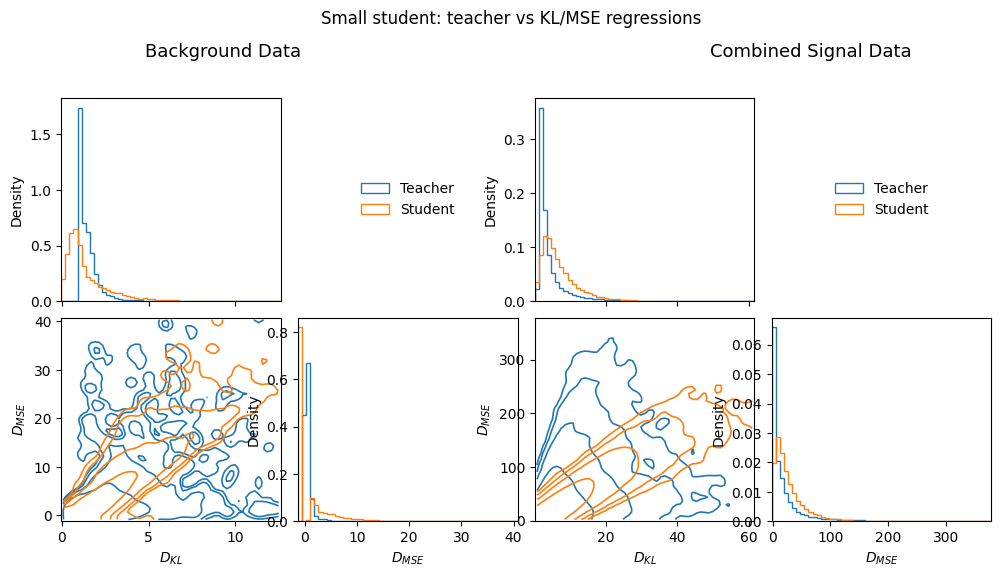

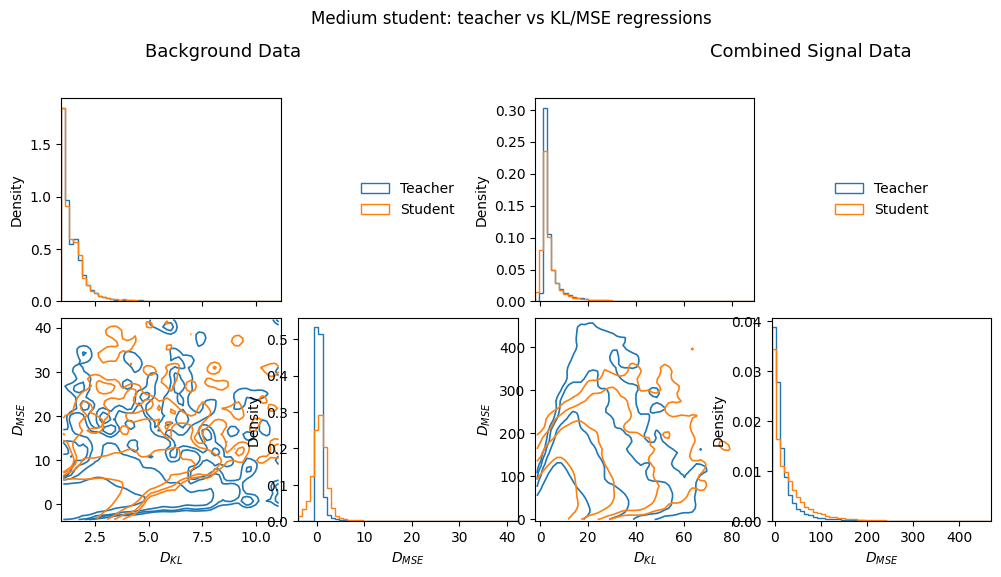

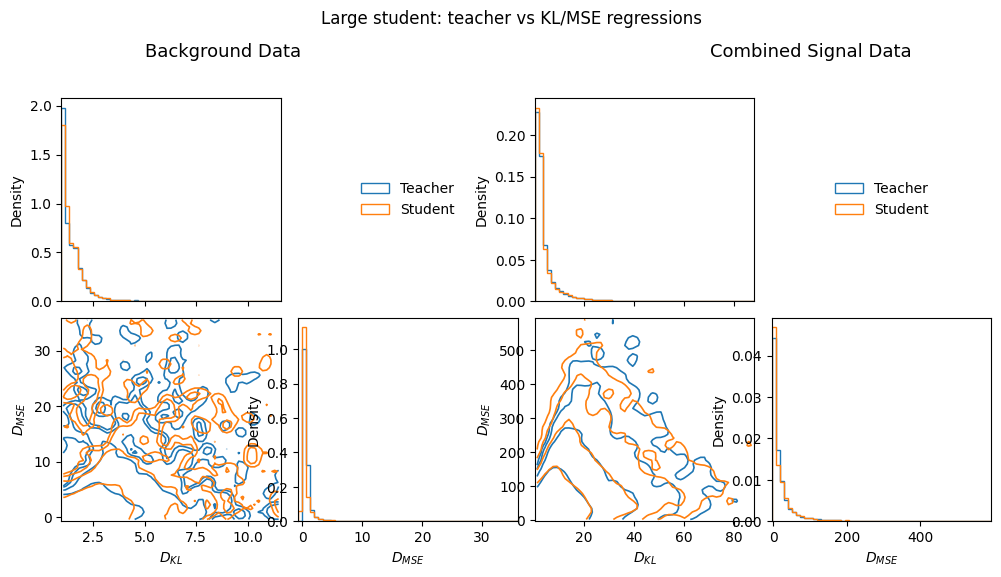

In [13]:
# STUDY 1 FLAG: choose "train" to fit and save all six students, or
# "load" to restore them from MODEL_DIR.
STUDY_1_MODE = "train"

base_models, base_scores = run_base_study(STUDY_1_MODE)


def _subsample_joint(x, y, max_points, seed):
    x = np.asarray(x)
    y = np.asarray(y)
    finite = np.isfinite(x) & np.isfinite(y)
    indices = np.flatnonzero(finite)
    if len(indices) > max_points:
        rng = np.random.default_rng(seed)
        indices = rng.choice(indices, size=max_points, replace=False)
    return x[indices], y[indices]


def _joint_scores(size_name, tags, max_points_per_tag=25_000):
    teacher_x, teacher_y, student_x, student_y = [], [], [], []
    for tag_index, tag in enumerate(tags):
        tx, ty = _subsample_joint(
            datasets[tag][TARGET_KEYS["KL"]], datasets[tag][TARGET_KEYS["MSE"]],
            max_points_per_tag, SEED + tag_index,
        )
        sx, sy = _subsample_joint(
            base_scores["KL"][size_name][tag], base_scores["MSE"][size_name][tag],
            max_points_per_tag, SEED + tag_index,
        )
        teacher_x.append(tx)
        teacher_y.append(ty)
        student_x.append(sx)
        student_y.append(sy)
    return tuple(np.concatenate(values) for values in (teacher_x, teacher_y, student_x, student_y))


def _draw_density_contour(ax, x, y, color, x_limits, y_limits):
    density, x_edges, y_edges = np.histogram2d(
        x, y, bins=55, range=[x_limits, y_limits], density=True
    )
    density = gaussian_filter(density, sigma=1.2)
    positive = density[density > 0]
    if positive.size == 0:
        return
    levels = np.unique(np.quantile(positive, [0.55, 0.72, 0.86, 0.95]))
    if levels.size:
        x_centers = (x_edges[:-1] + x_edges[1:]) / 2
        y_centers = (y_edges[:-1] + y_edges[1:]) / 2
        ax.contour(x_centers, y_centers, density.T, levels=levels, colors=color, linewidths=1.2)


def plot_teacher_student_corner(size_name):
    groups = [
        ("Background Data", ["Background"]),
        ("Combined Signal Data", SIGNAL_TAGS),
    ]
    fig = plt.figure(figsize=(12, 5.5))
    grid = fig.add_gridspec(2, 4, hspace=0.08, wspace=0.08)

    for group_index, (group_title, tags) in enumerate(groups):
        tx, ty, sx, sy = _joint_scores(size_name, tags)
        x_limits = np.nanpercentile(np.concatenate([tx, sx]), [0.5, 99.5])
        y_limits = np.nanpercentile(np.concatenate([ty, sy]), [0.5, 99.5])
        x_bins = np.linspace(*x_limits, 55)
        y_bins = np.linspace(*y_limits, 55)
        column = group_index * 2

        ax_kl = fig.add_subplot(grid[0, column])
        ax_joint = fig.add_subplot(grid[1, column])
        ax_mse = fig.add_subplot(grid[1, column + 1])
        ax_legend = fig.add_subplot(grid[0, column + 1])
        ax_legend.axis("off")

        ax_kl.hist(tx, bins=x_bins, density=True, histtype="step", color="tab:blue", label="Teacher")
        ax_kl.hist(sx, bins=x_bins, density=True, histtype="step", color="tab:orange", label="Student")
        ax_mse.hist(ty, bins=y_bins, density=True, histtype="step", color="tab:blue")
        ax_mse.hist(sy, bins=y_bins, density=True, histtype="step", color="tab:orange")
        _draw_density_contour(ax_joint, tx, ty, "tab:blue", x_limits, y_limits)
        _draw_density_contour(ax_joint, sx, sy, "tab:orange", x_limits, y_limits)

        ax_kl.set_xlim(x_limits)
        ax_joint.set_xlim(x_limits)
        ax_joint.set_ylim(y_limits)
        ax_mse.set_xlim(y_limits)
        ax_kl.set_xticklabels([])
        ax_joint.set_xlabel(r"$D_{KL}$")
        ax_joint.set_ylabel(r"$D_{MSE}$")
        ax_mse.set_xlabel(r"$D_{MSE}$")
        ax_kl.set_ylabel("Density")
        ax_mse.set_ylabel("Density")
        ax_legend.legend(*ax_kl.get_legend_handles_labels(), loc="center", frameon=False)
        fig.text(0.26 + 0.49 * group_index, 0.98, group_title, ha="center", va="top", fontsize=13)

    fig.suptitle(f"{size_name.capitalize()} student: teacher vs KL/MSE regressions", y=1.04)
    plt.show()


for student_size in ("small", "medium", "large"):
    plot_teacher_student_corner(student_size)

In [14]:
def _roc_values(background_scores, signal_scores):
    labels = np.concatenate([
        np.zeros(len(background_scores), dtype=np.int8),
        np.ones(len(signal_scores), dtype=np.int8),
    ])
    scores = np.concatenate([background_scores, signal_scores])
    fpr, tpr, _ = roc_curve(labels, scores)
    return fpr, tpr, auc(fpr, tpr)


def plot_size_rocs(size_scores, target_name, include_teacher=True):
    """For every signal, make separate medium- and large-family ROC figures."""
    for signal_tag in SIGNAL_TAGS:
        for family in ("medium", "large"):
            plt.figure(figsize=(8, 6))
            for architecture, scores_by_tag in size_scores[family].items():
                fpr, tpr, roc_auc = _roc_values(
                    scores_by_tag["Background"], scores_by_tag[signal_tag]
                )
                positive = (fpr > 0) & (tpr > 0)
                tpr_at_target = tpr[np.argmin(np.abs(fpr - 1e-5))]
                plt.plot(
                    fpr[positive], tpr[positive], linewidth=1.8,
                    label=f"{architecture}: AUC={roc_auc:.3f}, "
                          rf"$\epsilon_{{S}}(10^{{-5}})$={tpr_at_target:.2e}",
                )

            if include_teacher:
                teacher_key = TARGET_KEYS[target_name]
                fpr, tpr, roc_auc = _roc_values(
                    datasets["Background"][teacher_key], datasets[signal_tag][teacher_key]
                )
                positive = (fpr > 0) & (tpr > 0)
                plt.plot(
                    fpr[positive], tpr[positive], "k--", linewidth=2,
                    label=f"Teacher: AUC={roc_auc:.3f}",
                )

            plt.axvline(1e-5, color="0.5", linestyle=":", linewidth=1)
            plt.xscale("log")
            plt.yscale("log")
            plt.xlim(1e-6, 1)
            plt.ylim(1e-4, 1)
            plt.xlabel("False positive rate")
            plt.ylabel("True positive rate")
            plt.title(f"{signal_tag}: {family} students regressed to {target_name}")
            plt.grid(True, which="both", alpha=0.25)
            plt.legend(fontsize=8)
            plt.tight_layout()
            plt.show()

In [15]:
# Model predictions are kept in memory; the source HDF5 datasets are not rewritten.
# Trained model checkpoints are saved under MODEL_DIR by train_or_load_model().

## Study 2 — hidden-width scans and ROC comparisons

The width scans default to the KL target, matching the original student study. Change `SIZE_STUDY_TARGET` to `"MSE"` to run the same scan against the MSE teacher score.


Training size_medium_1 against MSE
Epoch 01 | train=372.153 | val=161.709 | lr=1.00e-03
Epoch 02 | train=368.326 | val=161.686 | lr=1.00e-03
Epoch 03 | train=368.308 | val=161.687 | lr=1.00e-03
Epoch 04 | train=368.305 | val=161.689 | lr=1.00e-03
Epoch 05 | train=368.305 | val=161.688 | lr=1.00e-03
Epoch 06 | train=368.304 | val=161.691 | lr=5.00e-04
Epoch 07 | train=368.304 | val=161.69 | lr=5.00e-04
Epoch 08 | train=368.304 | val=161.69 | lr=5.00e-04
Epoch 09 | train=368.304 | val=161.689 | lr=5.00e-04
Epoch 10 | train=368.304 | val=161.689 | lr=2.50e-04
Early stopping after 10 epochs
Saved best model (val=161.686) to /pscratch/sd/m/mcohen54/rajat_data/trained_models/size_medium_1_mse.pt

Training size_medium_4 against MSE
Epoch 01 | train=314.656 | val=107.747 | lr=1.00e-03
Epoch 02 | train=278.313 | val=104.169 | lr=1.00e-03
Epoch 03 | train=271.139 | val=103.164 | lr=1.00e-03
Epoch 04 | train=270.866 | val=103.845 | lr=1.00e-03
Epoch 05 | train=270.343 | val=103.899 | lr=1.00e-03

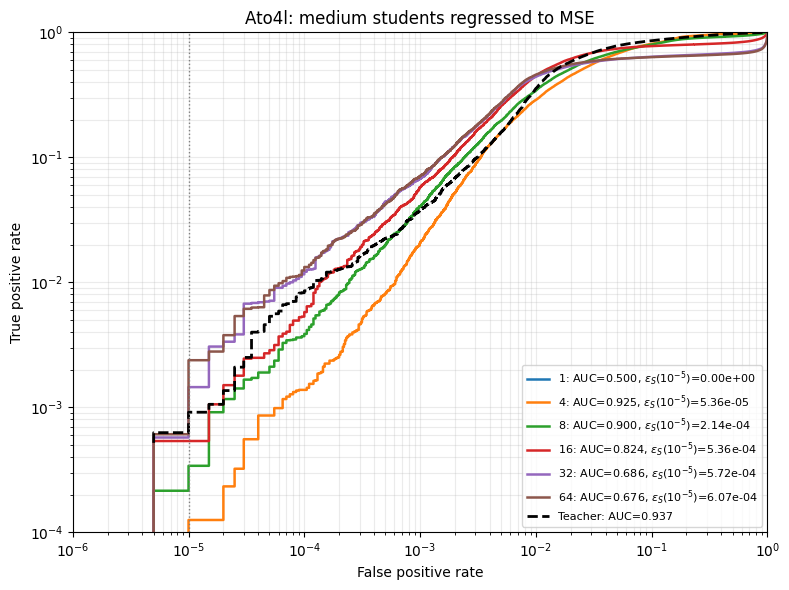

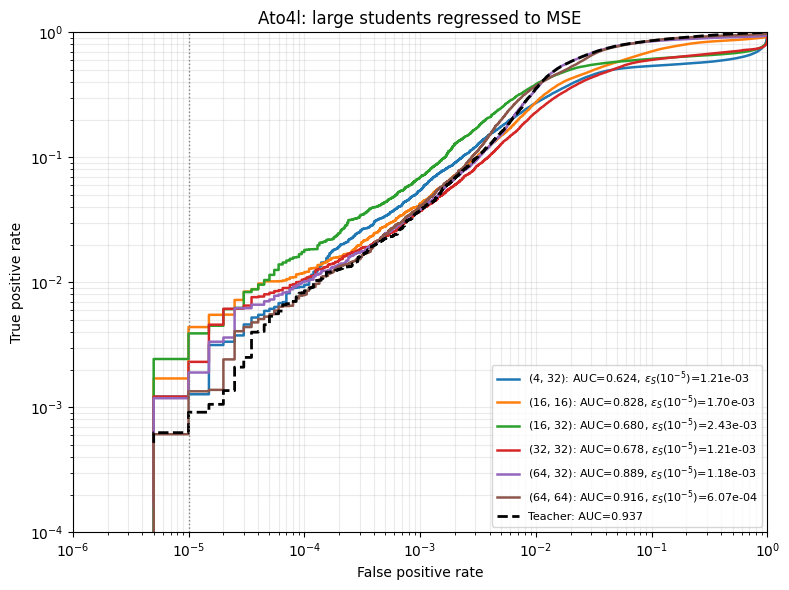

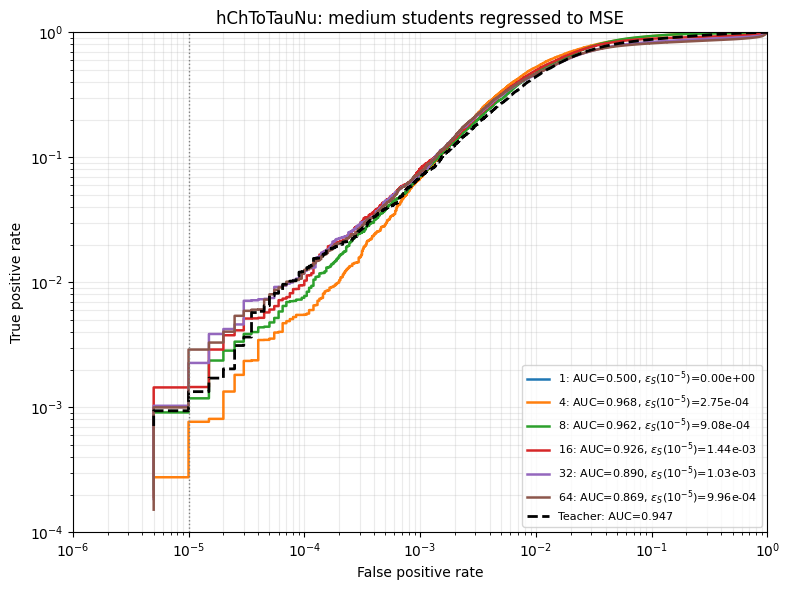

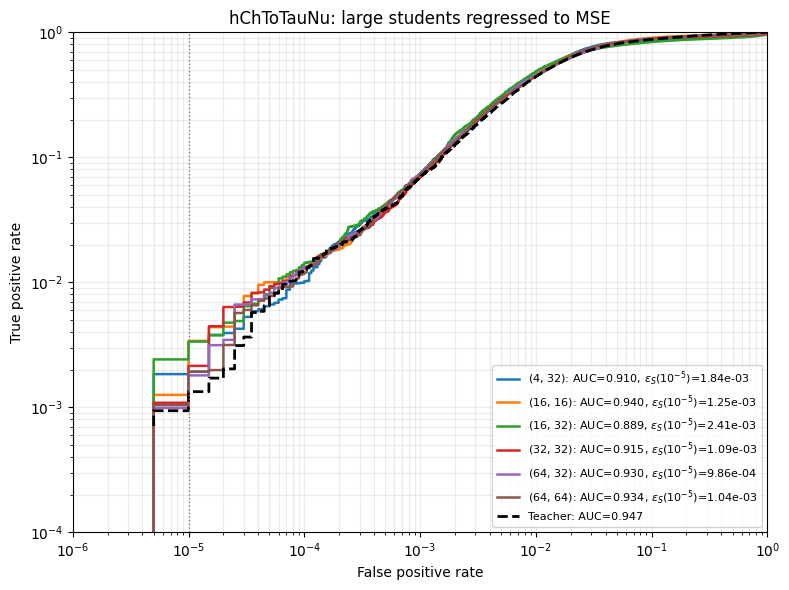

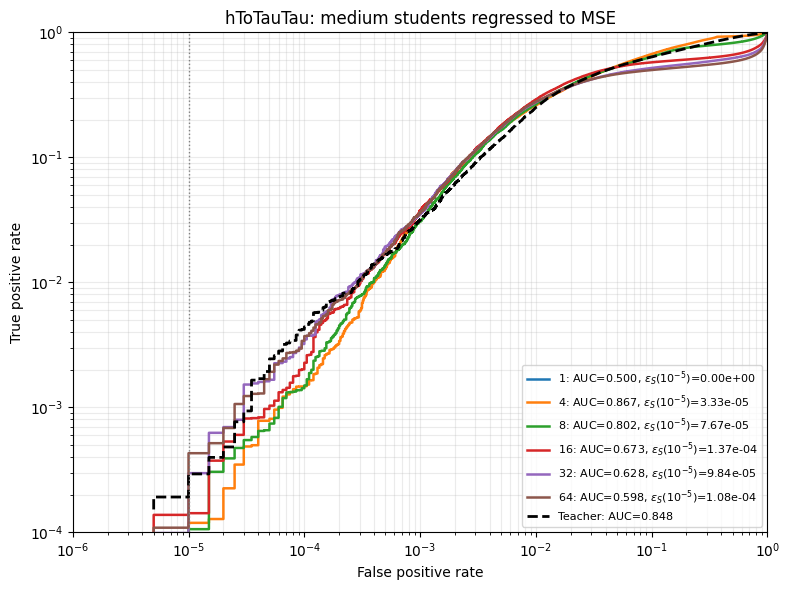

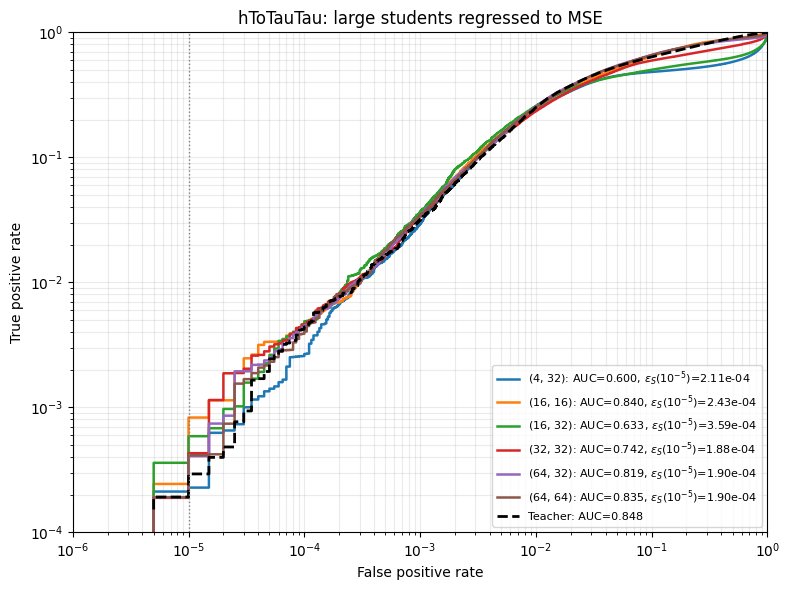

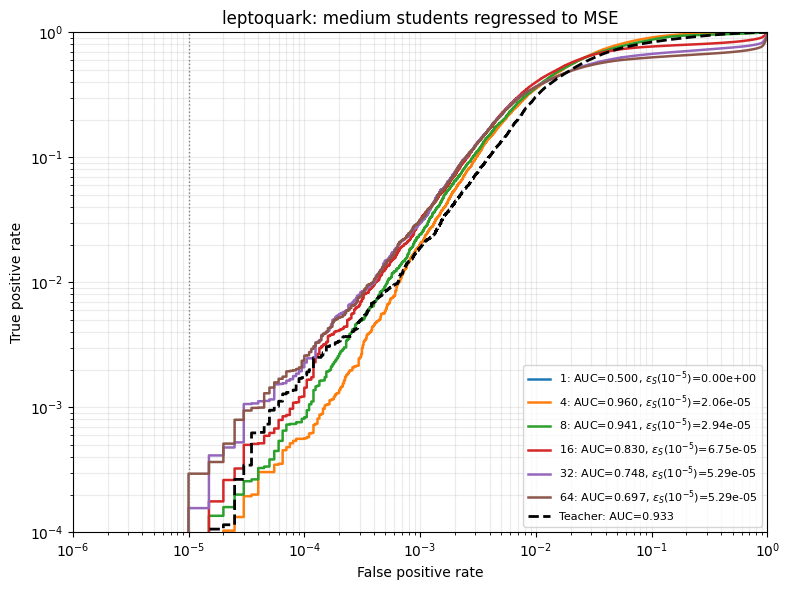

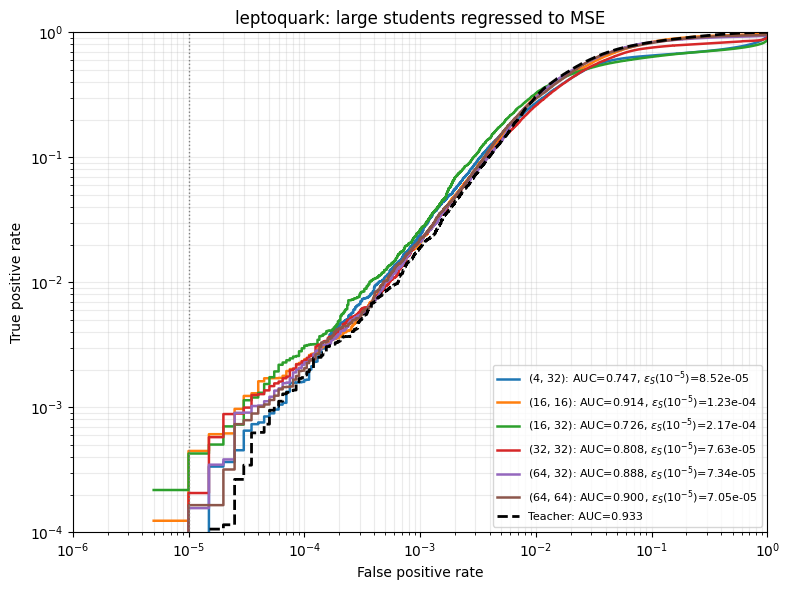

In [16]:
# STUDY 2 FLAG: "train" fits every requested width; "load" restores them.
STUDY_2_MODE = "load"
SIZE_STUDY_TARGET = "MSE"  # change to "MSE" to scan widths for the MSE target
INCLUDE_TEACHER_IN_ROCS = True

if SIZE_STUDY_TARGET not in TARGET_KEYS:
    raise ValueError(f"SIZE_STUDY_TARGET must be one of {tuple(TARGET_KEYS)}")

size_models, size_scores = run_size_study(STUDY_2_MODE, SIZE_STUDY_TARGET)
plot_size_rocs(size_scores, SIZE_STUDY_TARGET, include_teacher=INCLUDE_TEACHER_IN_ROCS)

In [17]:
def plot_size_score_histograms(size_scores, target_name, family):
    """Make one vertically stacked score-distribution figure for a model family."""
    architecture_scores = size_scores[family]
    tags = ["Background", *SIGNAL_TAGS]
    colors = dict(zip(tags, plt.cm.tab10.colors[:len(tags)]))

    percentile_ranges = []
    for scores_by_tag in architecture_scores.values():
        for tag in tags:
            values = scores_by_tag[tag]
            finite = values[np.isfinite(values)]
            percentile_ranges.append(np.percentile(finite, [0.2, 90]))
    low = min(bounds[0] for bounds in percentile_ranges)
    high = max(bounds[1] for bounds in percentile_ranges)
    bins = np.linspace(low, high, 80)

    fig, axes = plt.subplots(
        len(architecture_scores), 1,
        figsize=(10, 2.35 * len(architecture_scores)),
        sharex=True,
        squeeze=False,
    )
    for ax, (architecture, scores_by_tag) in zip(axes[:, 0], architecture_scores.items()):
        for tag in tags:
            values = scores_by_tag[tag]
            finite = values[np.isfinite(values)]
            ax.hist(
                finite, bins=bins, density=True, histtype="step",
                linewidth=1.3, color=colors[tag], label=tag,
            )
            ax.axvline(
                np.median(finite), color=colors[tag], linestyle=":",
                linewidth=1, alpha=0.9,
            )
        ax.set_ylabel("Density")
        ax.set_title(f"{family} {architecture}", fontsize=10)
        ax.grid(True, alpha=0.2)

    axes[0, 0].legend(loc="upper right", fontsize=8)
    axes[-1, 0].set_xlabel(f"Student score (regressed to {target_name})")
    fig.suptitle(f"{family.capitalize()} hidden-size score distributions", y=1.0)
    fig.tight_layout()
    plt.show()

Loaded size_medium_1 (MSE) from /pscratch/sd/m/mcohen54/rajat_data/trained_models/size_medium_1_mse.pt
Loaded size_medium_4 (MSE) from /pscratch/sd/m/mcohen54/rajat_data/trained_models/size_medium_4_mse.pt
Loaded size_medium_8 (MSE) from /pscratch/sd/m/mcohen54/rajat_data/trained_models/size_medium_8_mse.pt
Loaded size_medium_16 (MSE) from /pscratch/sd/m/mcohen54/rajat_data/trained_models/size_medium_16_mse.pt
Loaded size_medium_32 (MSE) from /pscratch/sd/m/mcohen54/rajat_data/trained_models/size_medium_32_mse.pt
Loaded size_medium_64 (MSE) from /pscratch/sd/m/mcohen54/rajat_data/trained_models/size_medium_64_mse.pt
Loaded size_large_4x32 (MSE) from /pscratch/sd/m/mcohen54/rajat_data/trained_models/size_large_4x32_mse.pt
Loaded size_large_16x16 (MSE) from /pscratch/sd/m/mcohen54/rajat_data/trained_models/size_large_16x16_mse.pt
Loaded size_large_16x32 (MSE) from /pscratch/sd/m/mcohen54/rajat_data/trained_models/size_large_16x32_mse.pt
Loaded size_large_32x32 (MSE) from /pscratch/sd/m/m

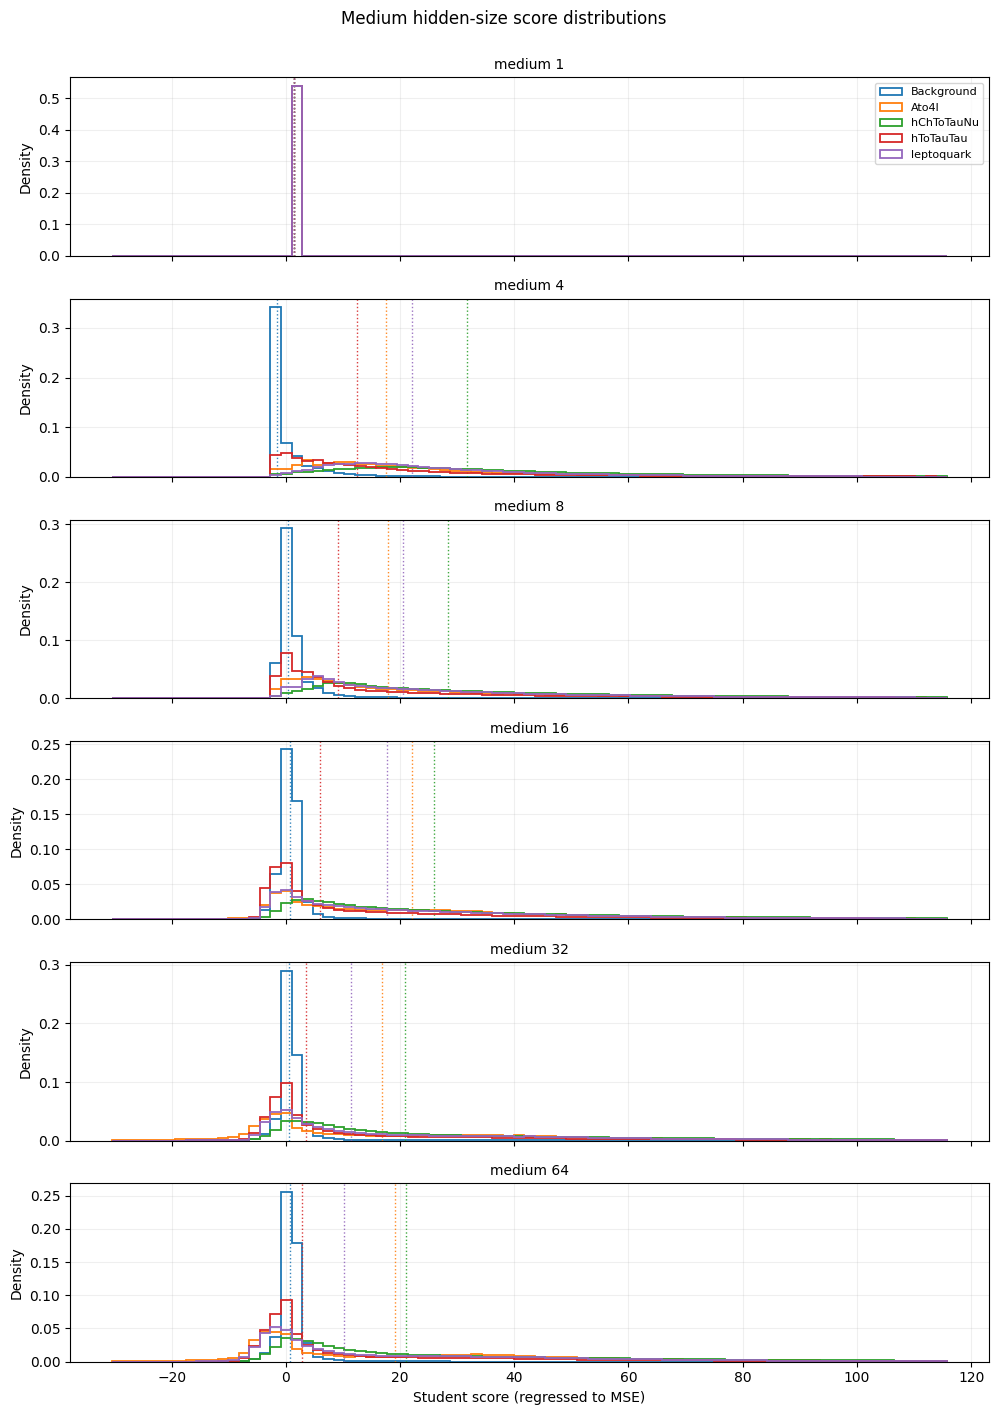

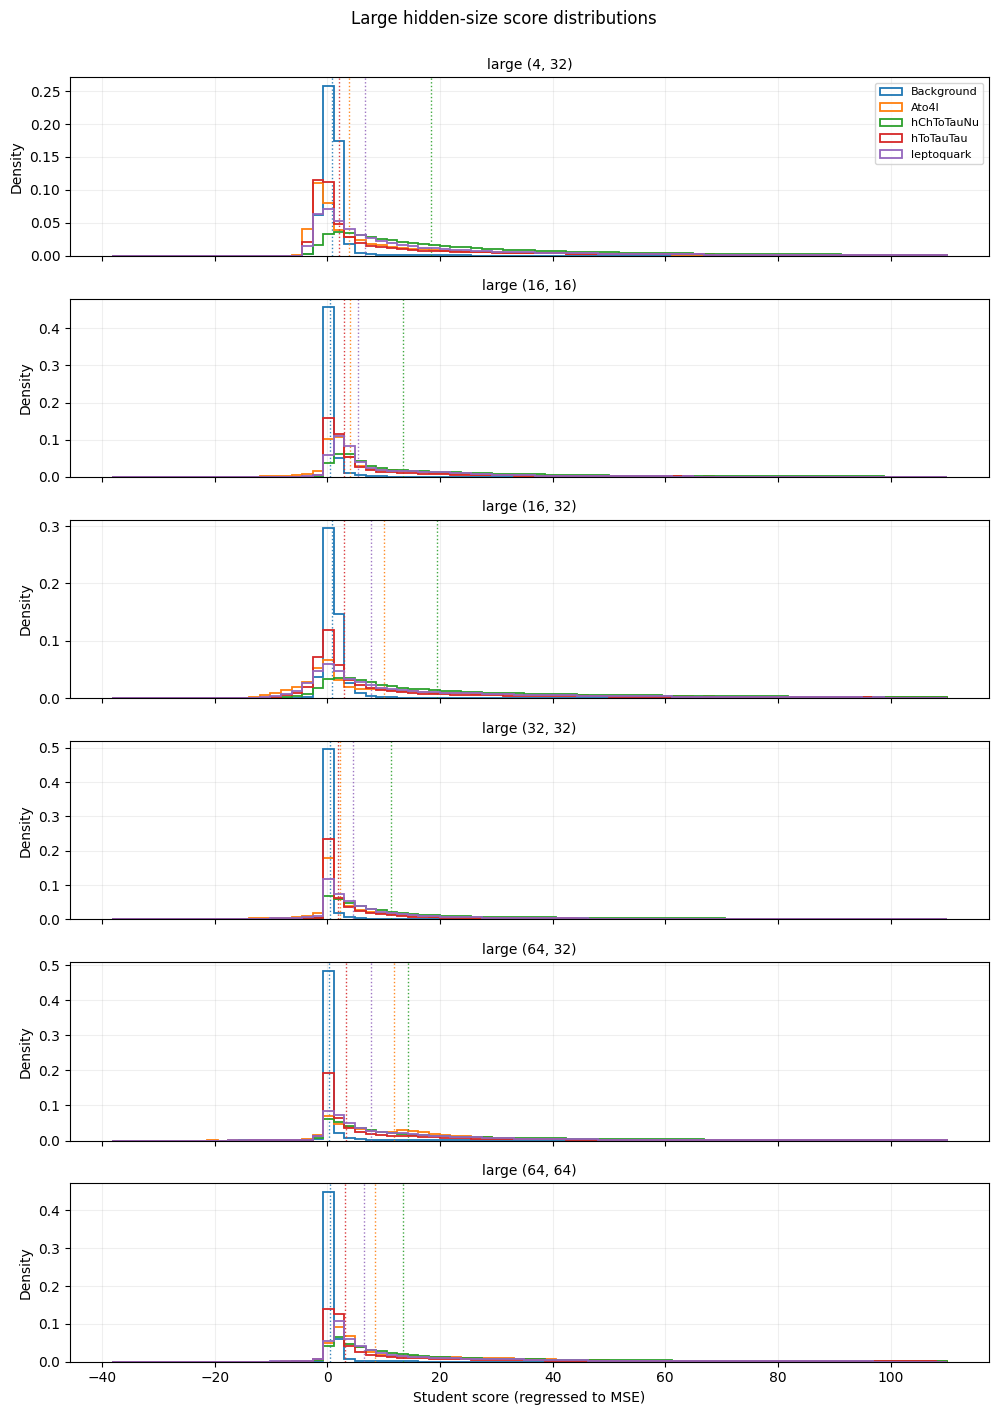

In [18]:
# STUDY 3 FLAG: this study can independently train or load the width-scan models.
STUDY_3_MODE = "load"
HISTOGRAM_TARGET = "MSE"  # change to "MSE" if those width-scan checkpoints exist

if HISTOGRAM_TARGET not in TARGET_KEYS:
    raise ValueError(f"HISTOGRAM_TARGET must be one of {tuple(TARGET_KEYS)}")

# Reuse Study 2 predictions when possible; otherwise honor this study's flag.
if (
    STUDY_3_MODE == "load"
    and "size_scores" in globals()
    and HISTOGRAM_TARGET == globals().get("SIZE_STUDY_TARGET")
):
    histogram_scores = size_scores
else:
    histogram_models, histogram_scores = run_size_study(STUDY_3_MODE, HISTOGRAM_TARGET)

plot_size_score_histograms(histogram_scores, HISTOGRAM_TARGET, "medium")
plot_size_score_histograms(histogram_scores, HISTOGRAM_TARGET, "large")